In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import json
import k3d
import lc_reconstruction_analysis.utils as utils
import lc_reconstruction_analysis.dendritic as dendritic
import lc_reconstruction_analysis.clustering as clustering
import lc_reconstruction_analysis.axon as axon
import lc_reconstruction_analysis.correlation as correlation
%matplotlib inline

## Assemble data

In [2]:
DATA_DIR = Path("../data/LC_Snapshots")
BASE_DIR = Path("../data/")

In [3]:
dataDF, graphs = utils.load_cells(DATA_DIR)

None
N004-648434: Axon and Dendrite
N006-648434: Axon and Dendrite
N011-648434: Axon and Dendrite
N012-648434: Axon and Dendrite
N020-648434: Axon and Dendrite
N023-648434: backbone available (Axon and Dendrite)
N024-648434: backbone available
N001-721332: after this point branch is not visible but this may be [13838.308,10281.643,22164.684] possible extension as per the continuation and reference of neighboring neurons.-need suggestion
N002-721332: Problem end-this is the main axonal back bone [13211.385,23928.03,23305.432]-which seems abruptly ending due to artefact but we are not sure it might be  continue here at [14067.628,24316.65,23063.537] need your suggestion for further extension.
N006-721332: Problem end-after this point branch is not visible[17829.0,5920.0,21514.0]
N016-721332: The main axonal back bone seems to abruptly end here at [6992.5903,15001.891,17753.77]; not sure about further ext.
N004-685222: Cell is not complete, needs to be extended here:[33828.62,14689.243,16

In [4]:
dataDF

,Graph,ID,Sample,Genotype,somaAP,somaDV,somaML,Annotator 1,Annotator 2,Time to Trace (hrs),Assigned Type,Segmentation Version,Horta Coordinates,somaOnRight
0,N001-685221,N001,685221,Dbh-Cre-KI/wt,10202.0168,4566.1902,4615.2926,Peter Grotz,NaN,5.00,Manual,NaN,"[30653.025, 10237.441, 10963.573]",False
1,N001-685222,N001,685222,Dbh-Cre-KI/wt,10354.5091,4146.1759,4725.1551,Shirali Amin,NaN,112.25,Manual,NaN,"[15834.622, 10044.901, 15855.611]",True
2,N001-721332,N001,721332,Dbh-Cre-KI/wt,10218.8658,4482.6014,4520.9614,Himani Parmar,NaN,44.20,Manual,NaN,"[14647.056, 16019.844, 12520.976]",False
3,N002-685222,N002,685222,Dbh-Cre-KI/wt,10570.1777,4321.9814,4732.3913,Hemal Diwanji,NaN,75.23,Manual,NaN,"[15141.219, 10326.347, 15781.027]",True
4,N002-721332,N002,721332,Dbh-Cre-KI/wt,10608.3358,4652.2092,4706.7961,Shirali Amin,NaN,23.50,Manual,NaN,"[13963.258, 10935.448, 14190.87]",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,N060-685221,N060,685221,Dbh-Cre-KI/wt,10169.9517,4718.8490,4771.5386,Yuvraju Venkatramraju,NaN,42.16,Manual,NaN,"[30672.572, 10619.404, 11365.582]",False
128,N061-685221,N061,685221,Dbh-Cre-KI/wt,10092.5036,5142.7198,4673.0799,Yashvi Patel,NaN,22.00,Manual,NaN,"[30737.326, 11579.554, 11115.847]",False
129,N063-685221,N063,685221,Dbh-Cre-KI/wt,10501.8416,4355.6694,5073.7626,Harsh Solanki,NaN,85.13,Manual,NaN,"[31359.992, 9559.311, 12192.574]",False
130,N064-685221,N064,685221,Dbh-Cre-KI/wt,10666.8768,4325.1543,4829.4285,Jinal Nukte,NaN,51.11,Manual,NaN,"[31814.39, 9396.24, 11531.573]",False


In [33]:
6194.48 / 24

258.1033333333333

In [11]:
# old_list = pd.read_csv("../results/LC reconstruction soma location and top projection (1).csv")
# old_list["Graph"]

0      N001-685221-PG
1      N001-685222-SA
2      N001-721332-HP
3      N002-685222-HD
4      N002-721332-SA
            ...      
125    N059-685221-SA
126    N060-685221-YV
127    N061-685221-YP
128    N063-685221-HS
129    N065-685221-HD
Name: Graph, Length: 130, dtype: object

In [12]:
dataDF[dataDF["ID"] == "N024"]

,Graph,ID,Sample,Genotype,somaAP,somaDV,somaML,Annotator 1,Annotator 2,Time to Trace (hrs),Assigned Type,Segmentation Version,Horta Coordinates,somaOnRight
75,N024-648434,N024,648434,Dbh-Cre-KI/wt,10908.8038,4402.3045,4605.7373,Shaily Shirke,Hemal Diwanji,31.39,NaN,NaN,"[30091.37, 9811.984, 12178.237]",True
76,N024-685221,N024,685221,Dbh-Cre-KI/wt,10299.8075,4850.2737,4615.7509,Vaidehi Maradia,NaN,18.24,Manual,NaN,"[31166.0, 10773.0, 16836.0]",True
77,N024-685222,N024,685222,Dbh-Cre-KI/wt,10216.7362,4899.8237,4688.8408,Anjana Patanvadiya,NaN,18.43,Manual,NaN,"[16251.03, 11627.03, 10521.0]",False


In [13]:
new_names = []
for name in old_list["Graph"]:
    neuronID, sample, _ = name.split("-")
    new_names = new_names + [neuronID + "-" + sample]

In [14]:
set(dataDF["Graph"].values) - set(new_names)

{'N024-648434', 'N064-685221'}

In [34]:
['N024-648434', 'N064-685221']

['N024-648434', 'N064-685221', 'N025-685221', 'N051-685221']

In [64]:
# old_list[old_list["Graph"] == "N025-685221-YP"]

In [36]:
old_list["Graph"]

0      N001-685221-PG
1      N001-685222-SA
2      N001-721332-HP
3      N002-685222-HD
4      N002-721332-SA
            ...      
125    N059-685221-SA
126    N060-685221-YV
127    N061-685221-YP
128    N063-685221-HS
129    N065-685221-HD
Name: Graph, Length: 130, dtype: object

In [29]:
dataDF[dataDF["ID"] == "N067"]

,Graph,ID,Sample,Genotype,somaAP,somaDV,somaML,Annotator 1,Annotator 2,Time to Trace (hrs),Assigned Type,Segmentation Version,Horta Coordinates,somaOnRight


In [15]:
# Add annotation for brains with coiled spinal cords
dataDF["completeSC"] = False
dataDF.loc[dataDF["Sample"].isin(['721332']),"completeSC"] = True
sc_dataDF = dataDF[dataDF["completeSC"]]

# Manually annotate spinal cord projections
projectsSC = ['N030-685222', 'N048-685221', 'N044-685221', 'N014-685221', 'N022-685221', 'N054-685221', 'N052-685221', 'N041-685221', 'N038-685221', 'N005-685222',
 'N021-685222', 'N016-685221', 'N035-685221', 'N016-685222', 'N004-685222', 'N010-685222', 'N001-685221', 'N043-685221', 'N006-685222', 'N007-685222', 'N026-685222', 
 'N051-685221', 'N056-685221', 'N042-685221', "N015-721332", "N017-721332", "N009-648434", "N045-685221", "N034-685222", "N034-685221", "N057-685221", "N036-685221", 
 "N020-685221", "N015-685222", "N055-685221", "N058-685221", "N046-685221", "N060-685221", "N025-648434", "N013-685221", "N012-685222", "N013-685222", "N050-685221", 
 "N024-685221", "N008-685222", "N009-685222", "N024-685222", "N059-685221", "N012-648434", "N006-648434", "N025-685222", "N061-685221", "N030-685221", "N026-648434",
 "N001-721332", "N002-721332", "N004-721332", "N007-721332", "N014-721332", "N021-721332"]

# Add labels to dataframe
dataDF["isSpinalProjecting"] = False
dataDF.loc[dataDF["Graph"].isin(projectsSC),"isSpinalProjecting"] = True

In [16]:
dataDF.head(3)

,Graph,ID,Sample,Genotype,somaAP,somaDV,somaML,Annotator 1,Annotator 2,Time to Trace (hrs),Assigned Type,Segmentation Version,Horta Coordinates,somaOnRight,completeSC,isSpinalProjecting
0,N001-685221,N001,685221,Dbh-Cre-KI/wt,10202.0168,4566.1902,4615.2926,Peter Grotz,NaN,5.00,Manual,NaN,"[30653.025, 10237.441, 10963.573]",False,False,True
1,N001-685222,N001,685222,Dbh-Cre-KI/wt,10354.5091,4146.1759,4725.1551,Shirali Amin,NaN,112.25,Manual,NaN,"[15834.622, 10044.901, 15855.611]",True,False,False
2,N001-721332,N001,721332,Dbh-Cre-KI/wt,10218.8658,4482.6014,4520.9614,Himani Parmar,NaN,44.20,Manual,NaN,"[14647.056, 16019.844, 12520.976]",False,True,True


## Basic features (length and branching)

In [17]:
# Build length dataframe
lengthDF = clustering.build_length_df(dataDF,graphs,BASE_DIR,normalize_df=False)
lengthDF.head(3)

,TH,fiber tracts,Isocortex,CNU,HY,HPF,MB,OLF,CTXsp,VS,P,MY,Other,CB
N023-685221,18125.202055,23474.960027,204879.450144,19729.469571,10905.186189,8812.553944,15906.545120,39646.190104,15854.479977,1242.883955,6357.269018,2454.532874,11210.895811,0.000000
N041-685221,534.783686,40275.368741,113227.814333,12585.041987,9178.324089,29400.120414,30643.162692,8096.193580,1168.184625,3036.571462,29088.402611,13232.647382,10810.821527,47902.020077
N005-685221,6253.014961,18794.960902,294383.724080,7442.248525,9301.602318,836.571540,31817.269040,24034.233375,848.138027,1156.593664,7251.289587,0.000000,6886.323508,997.619390


In [18]:
# Get basic features, e.g. branching and length
axon_branch_dict = {}
dend_branch_dict = {}
dend_length_dict = {}
for name in dataDF["Graph"]:
    graph = graphs[name]
    # Get axonal branches
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2]
    axon_branch_dict[name] = len(axon_branch_nodes)
    # Get dendritic branches
    dend_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 3] # get dendritic branches
    dend_branch_dict[name] = len(dend_branch_nodes)
    # Get dendritic lengths
    dend_graph = graph.subgraph([node for node in graph.nodes() if (graph.nodes[node]["structure_id"] == 3) or (graph.nodes[node]["structure_id"] == 1)])
    dend_length_dict[name] = sum(dend_graph[u][v]["weight"] for u, v in dend_graph.edges) # total length

# Combine length and branching into one dataframe
metricsDF = pd.concat([pd.Series(lengthDF.sum(axis=1) / 10000, name = "Axon Length (cm)"),
            pd.Series(axon_branch_dict, name = "Axon Branches"), 
            pd.Series(dend_length_dict, name = "Dendrite Length (cm)") / 10000,
            pd.Series(dend_branch_dict, name = "Dendrite Branches")], axis = 1)
metricsDF.head(3)

,Axon Length (cm),Axon Branches,Dendrite Length (cm),Dendrite Branches
N023-685221,37.859962,494,0.351040,29
N041-685221,34.917946,688,0.308733,32
N005-685221,41.000359,646,0.424971,22


In [19]:
# Merge dataframes
featureDF = pd.merge(dataDF,metricsDF,left_on="Graph", right_index=True, how = "left")

#### Get MouseLight reconstructions for comparison

In [20]:
## Compare to general population of moprhologies via MouseLight cells
folderPath = BASE_DIR.joinpath("mouselight_public")
filePaths = [os.path.join(folderPath,fn) for fn in os.listdir(folderPath) if fn.endswith(".json")]
# Load graphs
ml_graphs = utils.load_graphs(filePaths)
# Initiate dataDF
i = 0
datasetDicts = {}
for key, val in ml_graphs.items():
    try:
        soma = [
            node
            for node in val.nodes()
            if val.nodes[node]["structure_id"] == 1
        ]  # Get soma nodes
        assert len(soma) == 1
        x, y, z = val.nodes[soma[0]]["pos"]
    except Exception:
        print(
            f"Error finding structures for: {key}, dropping from dataframe"
        )
        continue
    neuronDict = {
        "Graph": key,
        "ID": key,
        "somaAP": x,
        "somaDV": y,
        "somaML": z,
    }
    datasetDicts[i] = neuronDict
    i = i + 1

# Assemble dataframe
ml_dataDF = pd.DataFrame.from_dict(datasetDicts, orient="index")

In [21]:
# Get axonal lengths
ml_lengthDF = clustering.build_length_df(ml_dataDF, ml_graphs, BASE_DIR, normalize_df=False)
ml_lengthDF = ml_lengthDF.drop(list(set(ml_lengthDF.index) - set(ml_dataDF["Graph"]))) # Drop graphs not included in dataDF

# Get axon branching
ml_axon_branch_dict = {}
for name in ml_dataDF["Graph"]:
    graph = ml_graphs[name]
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2]
    ml_axon_branch_dict[name] = len(axon_branch_nodes)

# Combine length and branching into one dataframe
ml_featureDF = pd.DataFrame([pd.Series(ml_lengthDF.sum(axis=1) / 10000, name = "Axon Length (cm)"), 
                             pd.Series(ml_axon_branch_dict, name = "Axon Branches")]).T
ml_featureDF.head(3)

,Axon Length (cm),Axon Branches
AA0015,6.495602,258.0
AA0330,9.840050,118.0
AA0051,11.669337,265.0


### Axon length vs branching plotting

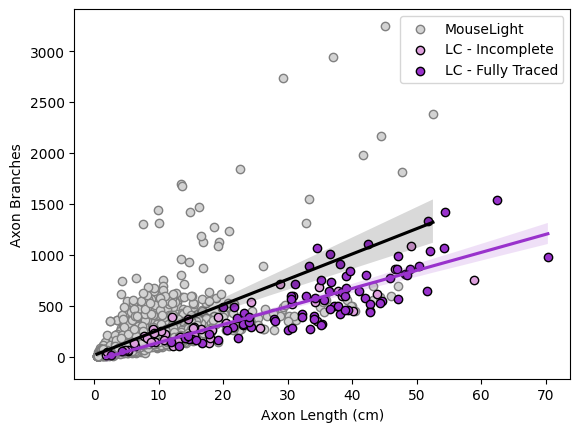

In [22]:
# Plot axon length vs branching
# Neurons with spinal cord projections from brains that do not have complete spinal cord may be incomplete.
incompleteMorphology = featureDF["isSpinalProjecting"] & ~featureDF["completeSC"]

# Plot both with and without regression
for reg in [True]: #[False, True]:
    plt.figure()
    # Plot Mouselight data for reference
    sns.scatterplot(ml_featureDF,x = "Axon Length (cm)", y = "Axon Branches", edgecolor = "gray", facecolor = "lightgray", linewidth = 1)
    
    # Plot LC reconstructions
    sns.scatterplot(featureDF[incompleteMorphology],x = "Axon Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "Plum", linewidth = 1)
    sns.scatterplot(featureDF[~incompleteMorphology],x = "Axon Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "DarkOrchid", linewidth = 1)
    plt.legend(["MouseLight","LC - Incomplete","LC - Fully Traced"])

    if reg:
        # Add regression line
        sns.regplot(ml_featureDF,x = "Axon Length (cm)", y = "Axon Branches", color = "black", scatter = False)
        sns.regplot(featureDF,x = "Axon Length (cm)", y = "Axon Branches", color = "DarkOrchid", scatter = False)
    plt.savefig(f"../results/LC and Mouselight length vs branch count reg = {reg}.svg",dpi=300,bbox_inches='tight')

## Projection figures

In [23]:
# Projection regions to look at
sorted_rois = ["OLF","Isocortex","HPF","CTXsp","CNU","TH","HY","MB","CB","P","MY","Other"]

In [24]:
# Get normalized features
normDF = pd.concat([lengthDF.divide(lengthDF.sum(axis = 1), axis = 0)[sorted_rois],
                    pd.Series(metricsDF["Axon Length (cm)"] / metricsDF["Axon Length (cm)"].max(), name = "Norm Axon Length"),
                    pd.Series(metricsDF["Axon Branches"] / metricsDF["Axon Branches"].max(), name = "Norm Axon Branches"),
                    pd.Series(metricsDF["Dendrite Length (cm)"] / metricsDF["Dendrite Length (cm)"].max(), name = "Norm Dend Length"),
                    pd.Series(metricsDF["Dendrite Branches"] / metricsDF["Dendrite Branches"].max(), name = "Norm Dend Branches")], axis = 1)
normDF.head(3)

,OLF,Isocortex,HPF,CTXsp,CNU,TH,HY,MB,CB,P,MY,Other,Norm Axon Length,Norm Axon Branches,Norm Dend Length,Norm Dend Branches
N023-685221,0.104718,0.541151,0.023277,0.041877,0.052112,0.047874,0.028804,0.042014,0.000000,0.016792,0.006483,0.029611,0.538357,0.321615,0.446929,0.617021
N041-685221,0.023186,0.324268,0.084198,0.003346,0.036042,0.001532,0.026285,0.087758,0.137185,0.083305,0.037896,0.030961,0.496523,0.447917,0.393066,0.680851
N005-685221,0.058620,0.718003,0.002040,0.002069,0.018152,0.015251,0.022687,0.077602,0.002433,0.017686,0.000000,0.016796,0.583013,0.420573,0.541055,0.468085


In [25]:
# Merge dataframes
fullDF = pd.merge(featureDF,normDF,left_on="Graph", right_index=True, how = "left")
fullDF["Most Length"] = [sorted_rois[i] for i in np.argmax(fullDF[sorted_rois],axis=1)] # Add top projection target

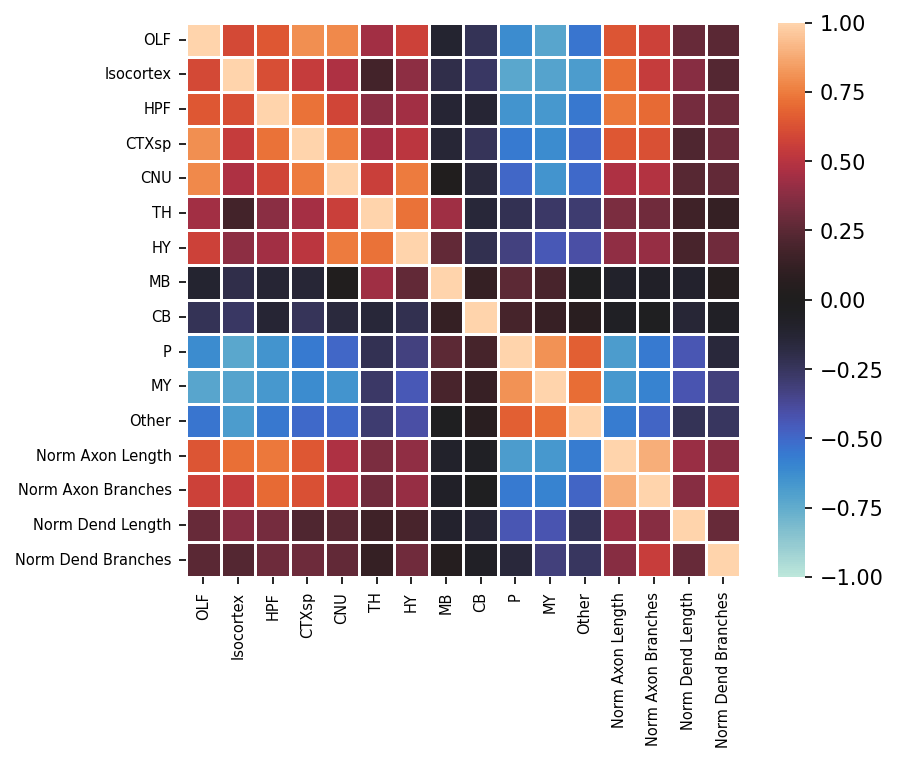

In [26]:
# Get correlation between features
corr_features = normDF.columns
corrMatrix = fullDF[corr_features].corr(method = "spearman")

# Do plotting
plt.figure(dpi=150)
sns.heatmap(corrMatrix, square = True, linewidths=.5, vmin = -1, vmax = 1, center = 0, cmap = "icefire")
plt.xticks(fontsize=7);
plt.yticks(fontsize=7);
plt.savefig("../results/Correlation matrix (spearman, proj + neuron features, diverging cmap).svg",
            dpi=300, bbox_inches='tight', transparent = True)

## Sort by top projection targets

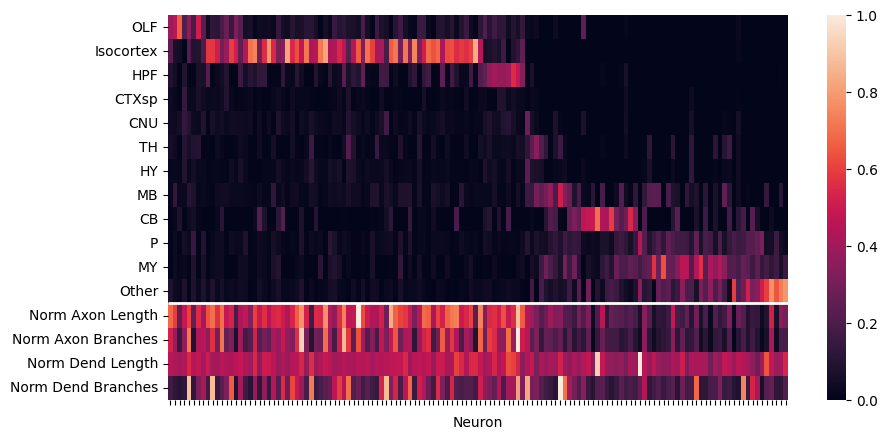

In [27]:
# Plot heatmap of projections
plotDF = fullDF.copy()
# Establish projection based sorting
sortProjDict = {}
for i, col in enumerate(sorted_rois):
    sortProjDict[col] = i
plotDF["Most Length"] = plotDF["Most Length"].map(sortProjDict)
plotDF = plotDF.sort_values("Most Length")[normDF.columns]

# Do plotting
plt.figure(figsize=(10,5))
sns.heatmap(plotDF.T, xticklabels = True, yticklabels = True)
# Clean up axes
plt.gca().set_xticklabels([])
plt.xlabel("Neuron")
plt.hlines([12], *plt.xlim(), colors = "white", linewidth = 2)
plt.savefig("../results/bilateral proj + neuron features heatmap sorted by top projection target.svg",
            dpi=300,bbox_inches='tight', transparent = True)

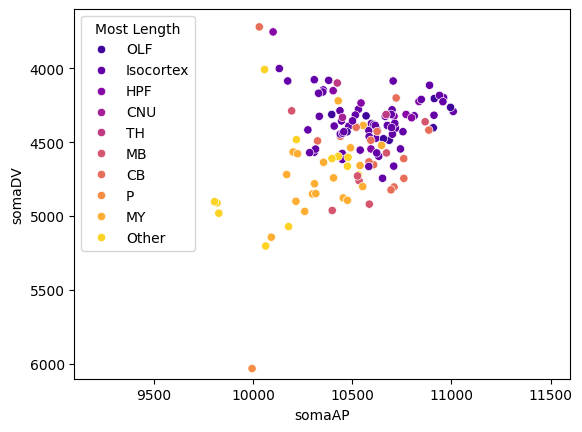

In [28]:
# Plot top projection target

# Only create colors for rois that are a top projection target
used_rois = sorted_rois.copy()
for indx in set(sorted_rois) - set(fullDF["Most Length"]):
    used_rois.remove(indx)

# Plot for several color palettes
for palette in ["plasma"]: # ["plasma","icefire","tab10","tab20"]:
    plt.figure()
    sns.scatterplot(fullDF,x = "somaAP", y = "somaDV", hue = "Most Length", palette = palette, hue_order= used_rois)
    plt.xlim([9100, 11600])
    plt.ylim([3600, 6100])
    plt.gca().invert_yaxis() # Invert the y-axis
    plt.savefig(f"../results/top projection target soma location {palette} palette.svg",dpi=300, bbox_inches='tight')

In [29]:
# Save a .csv of soma positions and top projection target
# Set up color mapping
colorDict = {}
for i, roi in enumerate(used_rois):
    colorDict[roi] = sns.color_palette("plasma",10)[i]

# Convert target to color, merge and save dataframe
df = fullDF["Most Length"].map(colorDict).apply(pd.Series)
df.columns = ["r", "g", "b"]
pd.merge(fullDF[["Graph","somaAP","somaDV","somaML","Most Length"]],df, left_index=True, right_index=True).to_csv("../results/LC reconstruction soma location and top projection.csv")

## Do 3d plotting

#### Plotting functions

In [30]:
# Establish camera views
topdownVertical = [12000, -10000, 5700, 9000, 0, 5700, -1, 0, 0]
topdownHorizontal = [9000, -9000, 5700, 9000, 0, 5700, 0, 0, 1]
topdownAngled = [7000, -12000, 0, 7000, 0, 5700, -.667, -.667, .167]
sideviewHorizontal = [7000, 5000, -8000, 7000, 4500, 5700, 0, -1, 0]

def load_obj(filename):
    """
    Load the vertices, vertex normals, and indices from a .obj file.

    Parameters:
    filename (str): Path to the .obj file

    Returns:
    tuple: A tuple containing three elements:
        - vertices (list of tuples): List of vertices, each vertex is a tuple (x, y, z)
        - normals (list of tuples): List of vertex normals, each normal is a tuple (nx, ny, nz)
        - indices (list of tuples): List of indices, each index is a tuple of vertex indices defining a face
    """
    vertices = []
    normals = []
    indices = []

    with open(filename, 'r') as file:
        for line in file:
            if line.startswith('v '):  # Vertex definition
                parts = line.split()
                vertices.append((float(parts[1]), float(parts[2]), float(parts[3])))
            elif line.startswith('vn '):  # Vertex normal definition
                parts = line.split()
                normals.append((float(parts[1]), float(parts[2]), float(parts[3])))
            elif line.startswith('f '):  # Face definition
                parts = line.split()
                # Extracting only the vertex indices (ignoring texture and normal indices)
                face_indices = [int(p.split('/')[0]) - 1 for p in parts[1:]]
                indices.append(tuple(face_indices))

    return vertices, normals, indices


def get_mesh_from_id(allen_id):
    obj_dir = "../data/ccf_2017_obj"
    obj_path = os.path.join(obj_dir, f"{allen_id}.obj")
    return load_obj(obj_path)

def rgb_to_hex(r,g,b):
    # Convert to a hexadecimal string
    hex_color = f'{r:02x}{g:02x}{b:02x}'
    # Convert the hexadecimal string to an integer in base-16
    color_int = int(hex_color, 16)
    return color_int

def plot_graphs(graphs, plot, color=0, opacity = 1, width = 1):
    for i, g in enumerate(graphs):
        g_lines = graph_to_lines(g, color, opacity, width)
        plot += g_lines

def graph_to_lines(g, color, opacity = 1, width = 1):
    # Extract vertex positions
    g_verts = np.array([g.nodes[n]['pos'] for n in sorted(g.nodes())], dtype=np.float32)
    # Pairs of indices into the vertex array are edges
    # Node keys start at 1, so offset by -1 to get indices
    g_inds = np.array([[u-1, v-1] for u, v in g.edges()], dtype=np.float32)
    g_lines = k3d.factory.lines(g_verts, g_inds, indices_type='segment', color=color, width=width, shader='simple', opacity = opacity)
    return g_lines

def plot_ccf_mesh(allen_id, plot, color=0x4d3d3d, opacity=0.1):
    vertices, normals, indices = get_mesh_from_id(allen_id)
    
    plt_tetra = k3d.mesh(
        vertices, 
        indices, 
        normals=normals,
        color=color,
        wireframe=False,
        opacity=opacity
    )

    plot += plt_tetra


# Get CCF lookups
from collections import defaultdict
ccf_structures = pd.read_csv('/data/allen_mouse_ccf/annotation/adult_mouse_ccf_structures.csv')
id_to_acronym = defaultdict(lambda: "NaN")
id_to_acronym = id_to_acronym | ccf_structures.set_index('id')['acronym'].to_dict()
acronym_to_id = {acronym: ccf_id for ccf_id, acronym in id_to_acronym.items()}

### Plot single neurons

In [49]:
# Plot single neuron, coloring out of bounds nodes
plotGraph = dataDF["Graph"].iloc[13] # ["N001-721332-HP"]
# plotGraph = "N022-648434-PG"
plotGraph = "N023-685222"

plot = k3d.plot()
plot_ccf_mesh(acronym_to_id['root'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
for i, name in enumerate(dataDF["Graph"]):
    if name in plotGraph:
        plot_graphs([graphs[name]],plot, opacity = .8)

# Set camera
plot.camera = sideviewHorizontal
plot.display()

Output()

In [47]:
plot.camera = sideviewHorizontal

In [40]:
# Save to PNG (requires the plot to be displayed on screen)
with open('../results/figure.png', 'wb') as f:
    # This may require an async yield or manual click in the UI
    f.write(plot.fetch_screenshot())

TypeError: a bytes-like object is required, not 'NoneType'

### Plot neurons colored by soma position

In [53]:
useSC = False
feature = "somaDV"

# Plot with or without full spinal cord projections, which may increase visual clarity
if useSC:
    plotDF = dataDF.copy()
else:
    plotDF = dataDF[~dataDF["completeSC"]].copy()

# Setup colors, and normalize plotting values
cmap = sns.color_palette("viridis", as_cmap=True)
nMin = 4200
nMax = 5000
normVals = (plotDF[feature] - nMin) / (nMax - nMin)
normVals = normVals.clip(0,1).rename("normVal")
# normVals = norm_values.clip(0,1).rename("normVal")
plotDF = pd.merge(plotDF, normVals, left_index=True, right_index=True)

# Do plotting
plot = k3d.plot()
plot_ccf_mesh(acronym_to_id['root'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
for i, row in plotDF.iterrows():
    graph = graphs[row["Graph"]]
    r, g, b, _ = cmap(row["normVal"])
    color = rgb_to_hex(int(r*255),int(g*255), int(b*255))
    plot_graphs([graph],plot, color, opacity = .8, width = 1)

# Set camera
plot.display()
plot.camera = sideviewHorizontal

Output()

In [55]:
plot.camera = sideviewHorizontal

### Do plotting

In [11]:
sharedDF[~sharedDF["isML"]][["Graph","Total Length (cm)", "Axon Branches"]].to_csv("../results/LC length and branching.csv")

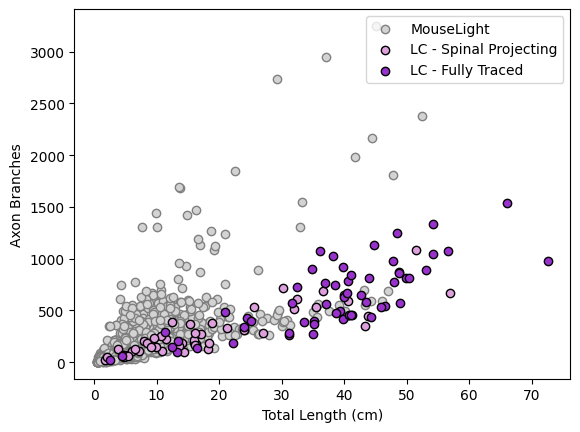

In [9]:
sns.scatterplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "gray", facecolor = "lightgray", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == True],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "Plum", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == False],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "DarkOrchid", linewidth = 1)
plt.legend(["MouseLight","LC - Spinal Projecting","LC - Fully Traced"])
# plt.savefig("../results/LC total length vs branch count.svg",dpi=300,bbox_inches='tight')
plt.savefig("../results/LC and Mouselight length vs branch count.svg",dpi=300,bbox_inches='tight')

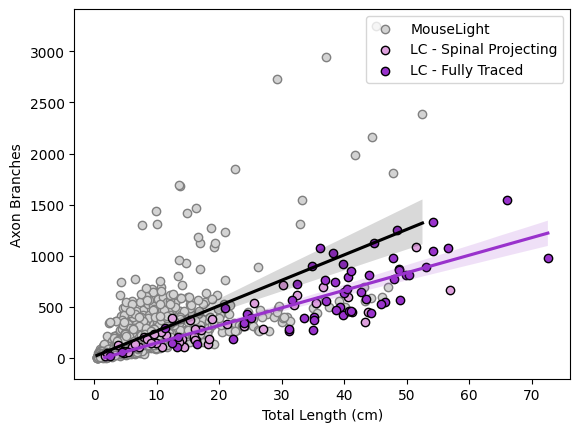

In [12]:
sns.scatterplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "gray", facecolor = "lightgray", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == True],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "Plum", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == False],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "DarkOrchid", linewidth = 1)
plt.legend(["MouseLight","LC - Spinal Projecting","LC - Fully Traced"])
sns.regplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "black", scatter = False)
sns.regplot(sharedDF[~sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "DarkOrchid", scatter = False)
plt.savefig("../results/LC and Mouselight length vs branch count with regression and CI.svg",dpi=300,bbox_inches='tight')

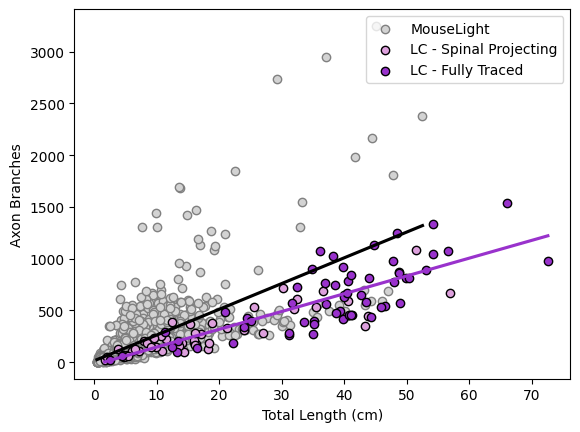

In [13]:
sns.scatterplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "gray", facecolor = "lightgray", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == True],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "Plum", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == False],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "DarkOrchid", linewidth = 1)
plt.legend(["MouseLight","LC - Spinal Projecting","LC - Fully Traced"])
sns.regplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "black", scatter = False, ci = None)
sns.regplot(sharedDF[~sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "DarkOrchid", scatter = False, ci = None)
plt.savefig("../results/LC and Mouselight length vs branch count with regression no CI.svg",dpi=300,bbox_inches='tight')

In [14]:
from scipy import stats

In [23]:
# Perform linear regression to get R-value
slope, intercept, r_value, p_value, std_err = stats.linregress(sharedDF[~sharedDF["isML"]]["Total Length (cm)"], 
                                                               sharedDF[~sharedDF["isML"]]["Axon Branches"])
# Calculate R-squared
r_squared = r_value**2
print(f"slope : {slope}")
print(f"intercept : {intercept}")
print(f"R^2 : {r_squared}")
print(f"pval : {p_value}")

slope : 17.18270815307419
intercept : -25.690499915328417
R^2 : 0.7410753595334758
pval : 7.081526440810124e-33


In [21]:
# Perform linear regression to get R-value
slope, intercept, r_value, p_value, std_err = stats.linregress(sharedDF[sharedDF["isML"]]["Total Length (cm)"], 
                                                               sharedDF[sharedDF["isML"]]["Axon Branches"])
# Calculate R-squared
r_squared = r_value**2
print(f"slope : {slope}")
print(f"intercept : {intercept}")
print(f"R^2 : {r_squared}")
print(f"pval : {p_value}")

slope : 24.870250026567188
intercept : 13.653056172509736
R^2 : 0.4172703801547808
pval : 7.864598272952046e-146


In [ ]:
sns.regplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "black", scatter = False)
sns.regplot(sharedDF[~sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "DarkOrchid", scatter = False)
# plt.savefig("../results/LC and Mouselight length vs branch count with regression and CI.svg",dpi=300,bbox_inches='tight')



<Axes: xlabel='Total Length (cm)', ylabel='Axon Branches'>

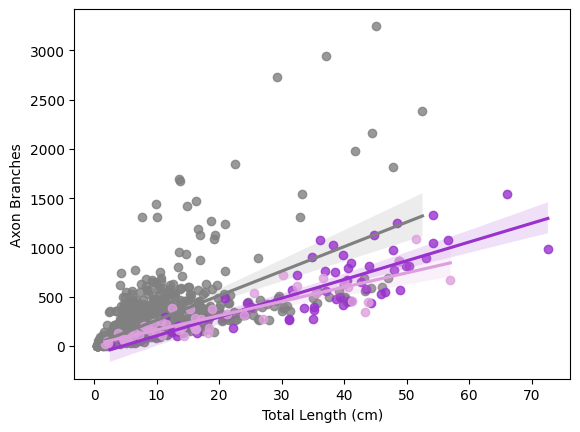

In [228]:
sns.regplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "gray")
sns.regplot(sharedDF[sharedDF["isSpinalProjecting"] == False],x = "Total Length (cm)", y = "Axon Branches", color = "DarkOrchid")
sns.regplot(sharedDF[sharedDF["isSpinalProjecting"] == True],x = "Total Length (cm)", y = "Axon Branches", color = "Plum")

In [239]:
from scipy import stats

# Assuming 'df' from the regplot example
slope, intercept, r_value, p_value, std_err = stats.linregress(sharedDF[sharedDF["isML"]]["Total Length (cm)"], sharedDF[sharedDF["isML"]]["Axon Branches"])

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")

Slope: 24.870250026567188
Intercept: 13.653056172509736
R-squared: 0.4172703801547808


In [243]:
from scipy import stats

# Assuming 'df' from the regplot example
slope, intercept, r_value, p_value, std_err = stats.linregress(sharedDF[~sharedDF["isML"]]["Total Length (cm)"], sharedDF[~sharedDF["isML"]]["Axon Branches"])

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")

Slope: 17.18270815307419
Intercept: -25.690499915328417
R-squared: 0.7410753595334758


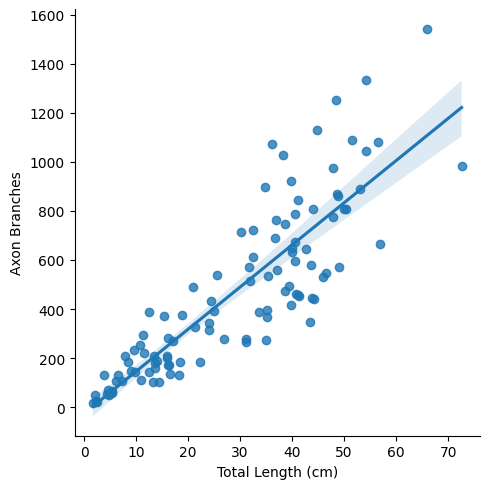

In [244]:
sns.lmplot(sharedDF[~sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches")

### Perform axon length vs branching stats

In [50]:
pip install pandas statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 87.3 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 59.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [51]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [317]:
# Establish dataframe for fitting
fitDF = sharedDF[~sharedDF["isML"]][["isSpinalProjecting", "Total Length (cm)","Axon Branches"]].copy() # Subset to just LC neurons
fitDF.loc[fitDF["isSpinalProjecting"] == True,"Group"] = "A" # Spinal projecting is group A
fitDF.loc[fitDF["isSpinalProjecting"] == False,"Group"] = "B" # Non spinal projecting is group B
fitDF = fitDF.drop(columns = "isSpinalProjecting")
fitDF = fitDF.rename(columns = {"Total Length (cm)":"DependentVar","Axon Branches":"Covariate"})
fitDF

,DependentVar,Covariate,Group
0,14.318932,103,A
1,72.567420,982,B
2,49.870732,809,B
3,39.771467,418,B
4,4.460401,56,B
...,...,...,...
103,9.654440,232,A
104,25.510407,538,A
105,9.106368,148,A
106,54.180260,1332,B


In [321]:
# Establish dataframe for fitting
fitDF = sharedDF[["isML", "Total Length (cm)","Axon Branches"]].copy()
fitDF.loc[fitDF["isML"],"Group"] = "A" # Mouselight group is A
fitDF.loc[~fitDF["isML"],"Group"] = "B" # LC group is B
fitDF = fitDF.drop(columns = "isML")
fitDF = fitDF.rename(columns = {"Total Length (cm)":"DependentVar","Axon Branches":"Covariate"})
fitDF

,DependentVar,Covariate,Group
0,14.318932,103,B
1,72.567420,982,B
2,49.870732,809,B
3,39.771467,418,B
4,4.460401,56,B
...,...,...,...
1330,6.958242,102,A
1331,6.196437,285,A
1332,6.148054,160,A
1333,3.703325,163,A


In [314]:
# ANCOVA model: DependentVar ~ Group + Covariate
model = smf.ols('DependentVar ~ Group + Covariate', data=fitDF).fit()

In [315]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           DependentVar   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     1072.
Date:                Mon, 22 Sep 2025   Prob (F-statistic):          3.95e-278
Time:                        23:56:54   Log-Likelihood:                -4322.6
No. Observations:                1335   AIC:                             8651.
Df Residuals:                    1332   BIC:                             8667.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.8927      0.221     17.612      0.0

In [325]:
model.pvalues

Intercept      1.401597e-62
Group[T.B]    1.038319e-107
Covariate     6.346891e-172
dtype: float64